In [1]:
import random
from tqdm import tqdm
from collections import defaultdict
def get_available_nodes(graph, source, hop=1):
    if hop == 0:
        return set(graph.keys()) - {source}
    current = {source}
    visited = {source}
    available_nodes = set()
    for _ in range(hop):
        next_level = set()
        for node in current:
            neighbors = graph[node]
            available_nodes.update(neighbors)
            for neighbor in neighbors:
                if neighbor not in visited:
                    visited.add(neighbor)
                    next_level.add(neighbor)
        current = next_level
        if not current:
            break
    available_nodes.discard(source)
    return available_nodes

def simulate(graph, victim, originator, available_nodes, p=1):
    if originator not in available_nodes:
        raise ValueError("Originator not in victim neighborhood")
    victim_neighbors = graph[victim]
    remaining = set(victim_neighbors)  # not yet infected
    current = {originator}
    visited = {originator}
    time = 0
    spread_time = 0
    if originator in remaining:
        remaining.remove(originator)

    while current and remaining:
        next_level = set()
        for node in current:
            neighbors = available_nodes & graph[node]
            for neighbor in neighbors:
                spread_prob = random.random()
                if neighbor not in visited and spread_prob <= p:
                    visited.add(neighbor)
                    next_level.add(neighbor)
                    if neighbor in remaining:
                        remaining.remove(neighbor)
                        spread_time = time + 1  # last infection time updates
                elif neighbor not in visited:
                    next_level.add(node)
        current = next_level
        time += 1
    victim_degree = len(victim_neighbors)
    infected = victim_neighbors - remaining
    spread_factor = len(infected) / victim_degree if victim_degree > 0 else 0

    return spread_time, spread_factor

def run_simulation_by_k(graph, hop=1, p=1):
    data_by_k = defaultdict(lambda: defaultdict(list))
    for victim, victim_node in graph.items():
        available_nodes = get_available_nodes(graph, victim, hop=hop)
        for originator in victim_node:
            data = simulate(graph, victim, originator, available_nodes, p)
            spread_time, spread_factor = data[0], data[1]
            k = len(victim_node)
            data_by_k[k]["spread_time"].append(spread_time)
            data_by_k[k]["spread_factor"].append(spread_factor)
    return data_by_k

In [2]:
import pickle
import os
def load_graphs(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

def save_results(results, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(results, f)

def to_dict(obj):
    if isinstance(obj, defaultdict):
        return {k: to_dict(v) for k, v in obj.items()}
    return obj

In [3]:
for p in [0.2, 0.4, 0.6, 0.8, 1.0]:
    if not os.path.exists(f"fig_data/fig14/fig14_m09_N01K_p{int(p*10)}.pkl"):
        result = defaultdict(lambda: defaultdict(list))
        BA_path = f"data/ba/ba_network_m09_N001K.pkl"
        BA_graphs = load_graphs(BA_path)
        print(f"Running simulation for m=09 , N=01K:")
        for graph in tqdm(BA_graphs):
            graph_result = run_simulation_by_k(graph, p=p)
            for k, metrics in graph_result.items():
                for metric, values in metrics.items():
                    result[k][metric].extend(values)
        result = to_dict(result)
        del BA_graphs
        save_results(result, f"fig_data/fig14/fig14_m09_N01K_p{int(p*10)}.pkl")
        del result

In [4]:
for p in [0.2, 0.4, 0.6, 0.8, 1.0]:
    if not os.path.exists(f"fig_data/fig14/fig14_p{int(p*10)}.pkl"):
        result = defaultdict(lambda: defaultdict(list))
        real_path = f"data/real_networks.pkl"
        real_graphs = load_graphs(real_path)
        print(f"Running simulation for real network:")
        for graph in tqdm(real_graphs.values()):
            graph_result = run_simulation_by_k(graph, p=p)
            for k, metrics in graph_result.items():
                for metric, values in metrics.items():
                    result[k][metric].extend(values)
        result = to_dict(result)
        del real_graphs
        save_results(result, f"fig_data/fig14/fig14_p{int(p*10)}.pkl")
        del result

Fig 14a


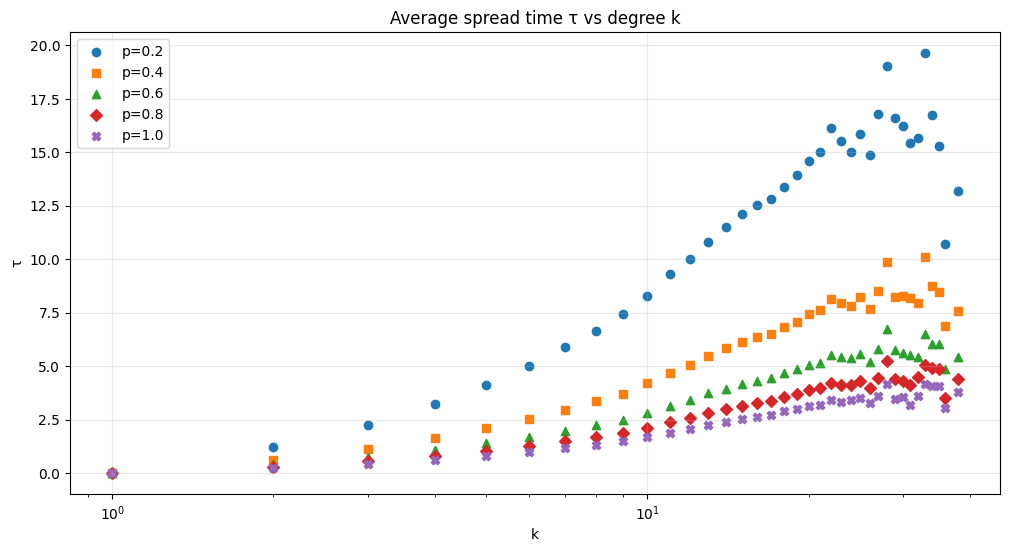

In [8]:
import matplotlib.pyplot as plt
import numpy as np
markers = {
    0.2: "o",
    0.4: "s",
    0.6: "^",
    0.8: "D",
    1.0: "X"
}

#Spread time
plt.figure(figsize=(12, 6))
for p in [0.2, 0.4, 0.6, 0.8, 1.0]:
    real_data_by_k = load_graphs(f"fig_data/fig14/fig14_p{int(p * 10)}.pkl")
    real_plot_data_by_k = defaultdict(dict)
    for k in real_data_by_k:
        real_plot_data_by_k[k]["spread_time"] = sum(real_data_by_k[k]["spread_time"]) / len(real_data_by_k[k]["spread_time"])
    ks = np.array(sorted(real_plot_data_by_k))
    spread_times = np.array([real_plot_data_by_k[k]["spread_time"] for k in ks])
    plt.scatter(ks, spread_times, label=f"p={p}", marker=markers[p])
    del real_data_by_k, real_plot_data_by_k

print("Fig 14a")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("τ")
plt.title("Average spread time τ vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 14a


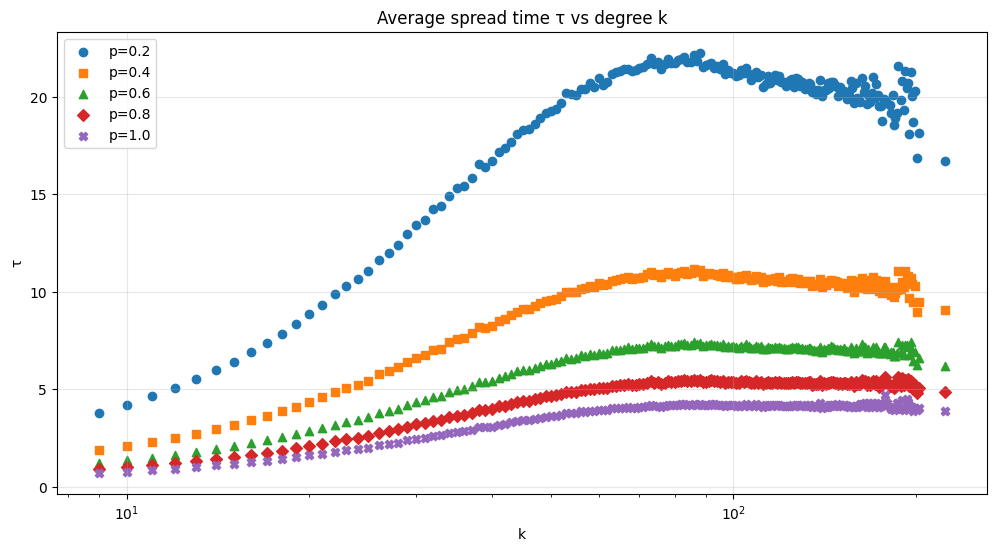

In [9]:
#Spread time
plt.figure(figsize=(12, 6))
for p in [0.2, 0.4, 0.6, 0.8, 1.0]:
    BA_data_by_k = load_graphs(f"fig_data/fig14/fig14_m09_N01K_p{int(p * 10)}.pkl")
    BA_plot_data_by_k = defaultdict(dict)
    for k in BA_data_by_k:
        BA_plot_data_by_k[k]["spread_time"] = sum(BA_data_by_k[k]["spread_time"]) / len(BA_data_by_k[k]["spread_time"])
    ks = np.array(sorted(BA_plot_data_by_k))
    spread_times = np.array([BA_plot_data_by_k[k]["spread_time"] for k in ks])
    plt.scatter(ks, spread_times, label=f"p={p}", marker=markers[p])
    del BA_data_by_k, BA_plot_data_by_k

print("Fig 14a")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("τ")
plt.title("Average spread time τ vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 14b


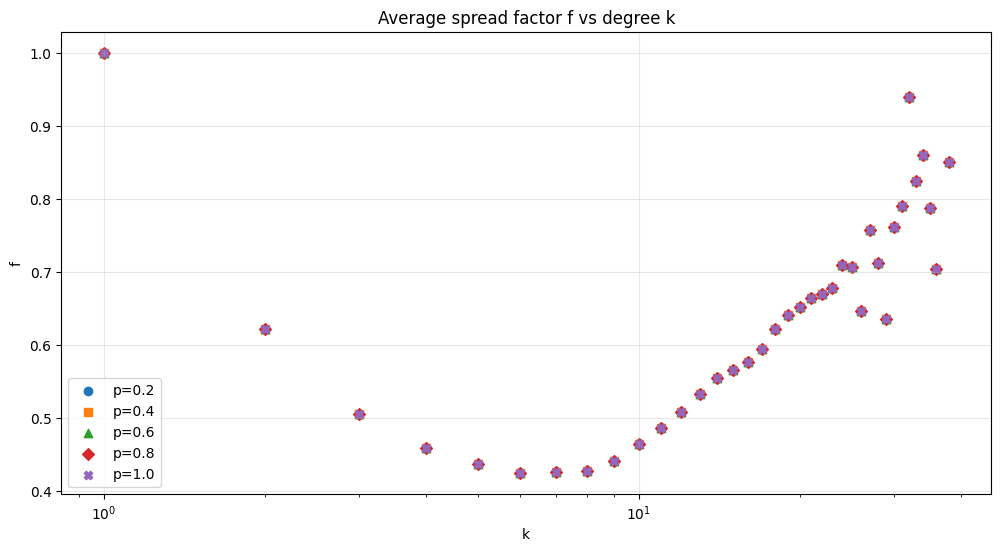

In [10]:
#Spread factor
plt.figure(figsize=(12, 6))
for p in [0.2, 0.4, 0.6, 0.8, 1.0]:
    real_data_by_k = load_graphs(f"fig_data/fig14/fig14_p{int(p * 10)}.pkl")
    real_plot_data_by_k = defaultdict(dict)
    for k in real_data_by_k:
        real_plot_data_by_k[k]["spread_factor"] = sum(real_data_by_k[k]["spread_factor"]) / len(real_data_by_k[k]["spread_factor"])
    ks = np.array(sorted(real_plot_data_by_k))
    spread_factors = np.array([real_plot_data_by_k[k]["spread_factor"] for k in ks])
    plt.scatter(ks, spread_factors, label=f"p={p}", marker=markers[p])
    del real_data_by_k, real_plot_data_by_k

print("Fig 14b")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("f")
plt.title("Average spread factor f vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 14b inset


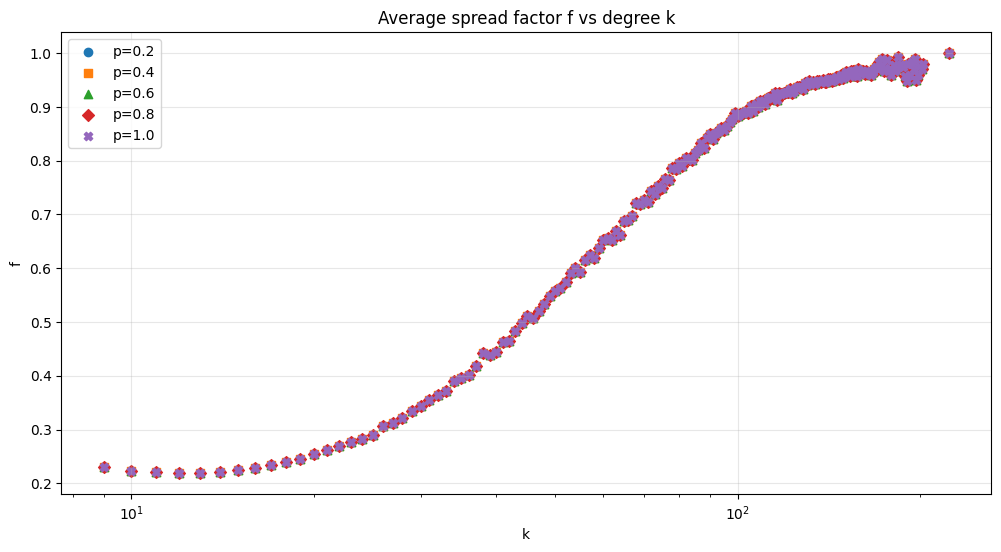

In [11]:
#Spread factor
plt.figure(figsize=(12, 6))
for p in [0.2, 0.4, 0.6, 0.8, 1.0]:
    real_data_by_k = load_graphs(f"fig_data/fig14/fig14_m09_N01K_p{int(p * 10)}.pkl")
    real_plot_data_by_k = defaultdict(dict)
    for k in real_data_by_k:
        real_plot_data_by_k[k]["spread_factor"] = sum(real_data_by_k[k]["spread_factor"]) / len(real_data_by_k[k]["spread_factor"])
    ks = np.array(sorted(real_plot_data_by_k))
    spread_factors = np.array([real_plot_data_by_k[k]["spread_factor"] for k in ks])
    plt.scatter(ks, spread_factors, label=f"p={p}", marker=markers[p])
    del real_data_by_k, real_plot_data_by_k

print("Fig 14b inset")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("f")
plt.title("Average spread factor f vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()